In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
import seaborn as sns

In [6]:
# 1. Load the data, skipping the metadata header rows
DATA_DIR = "../data"
file_path = '{}/avia_paocc__custom_20420811_spreadsheet.xlsx'.format(DATA_DIR)
df = pd.read_excel(file_path, sheet_name='Sheet 1', skiprows=10)

# 2. Clean up the columns
# Eurostat often includes empty columns between quarters; we drop them
df = df.dropna(axis=1, how='all')

# 3. Handle missing values
# Eurostat uses ':' for missing data. We'll replace it with 0 or NaN.
df = df.replace(':', pd.NA)

# 4. View the result
print(f"Data Loaded: {df.shape[0]} countries and {df.shape[1]} time periods.")
df.head()

Data Loaded: 43 countries and 105 time periods.


,TIME,2000-Q1,2000-Q2,2000-Q3,2000-Q4,2001-Q1,2001-Q2,2001-Q3,2001-Q4,2002-Q1,...,2023-Q3,2023-Q4,2024-Q1,2024-Q2,2024-Q3,2024-Q4,2025-Q1,2025-Q2,2025-Q3,2025-Q4
0,GEO (Labels),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,European Union - 27 countries (from 2020),<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,157485333,113992942,98898814,145700249,167609125,121017016,102356481,149631551,<NA>,<NA>
2,European Union - 28 countries (2013-2020),<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,European Union - 27 countries (2007-2013),<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,Belgium,2525721,3575929,3933882,2970297,<NA>,<NA>,<NA>,<NA>,1285064,...,6452993,5096840,4505608,6371014,6873457,5470087,4654837,6346489,7087659,<NA>


In [12]:
# Identify the ID column (the country name)
id_col = 'TIME' # In this file, 'TIME' is the header for the country list

# Melt the dataframe
df_long = df.melt(id_vars=[id_col], var_name='Quarter', value_name='Passengers')

# Clean the passenger counts (convert to numbers)
df_long['Passengers'] = pd.to_numeric(df_long['Passengers'], errors='coerce')

# Rename the country column for clarity
df_long = df_long.rename(columns={id_col: 'Country'})

print(df.shape)
df_long.head()

(43, 105)


,Country,Quarter,Passengers
0,GEO (Labels),2000-Q1,NaN
1,European Union - 27 countries (from 2020),2000-Q1,NaN
2,European Union - 28 countries (2013-2020),2000-Q1,NaN
3,European Union - 27 countries (2007-2013),2000-Q1,NaN
4,Belgium,2000-Q1,2525721.0


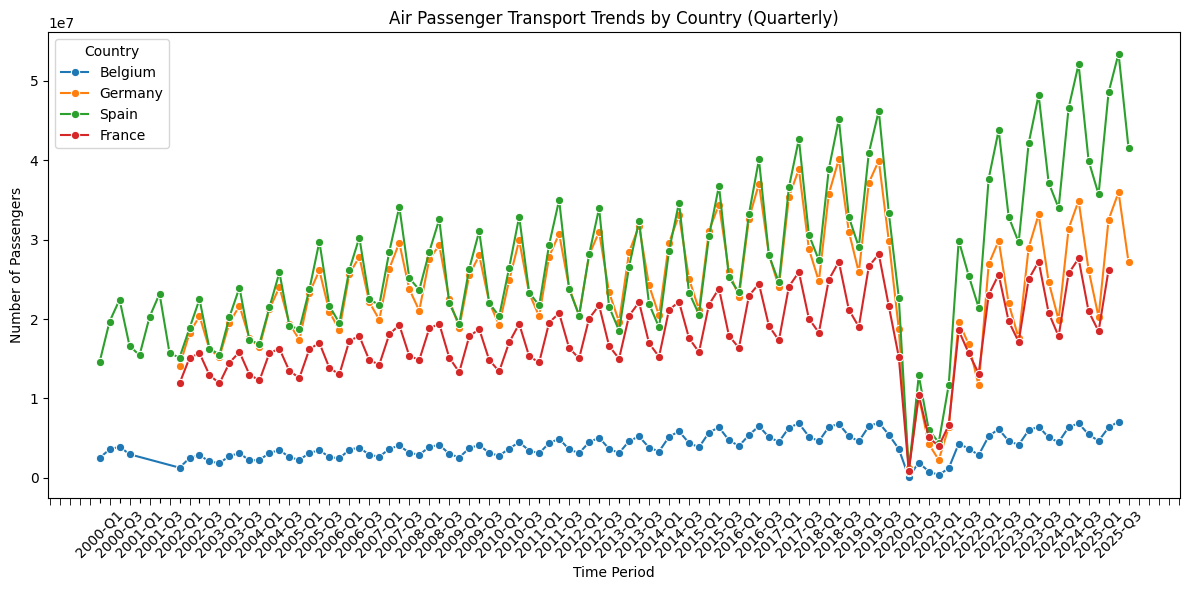

In [ ]:
# Filter for specific regions to compare
targets = ['Belgium', 'Germany', 'Spain', 'France']
comparison = df_long[df_long['Country'].isin(targets)]

# Create the plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=comparison, x='Quarter', y='Passengers', hue='Country', marker='o')

all_quarters = comparison['Quarter'].unique()


plt.title('Air Passenger Transport Trends by Country (Quarterly)')
plt.xticks(
    ticks=range(0, len(all_quarters), 2), 
    labels=all_quarters[::2], 
    rotation=45
)

# Done with AI
ax = plt.gca() # Get the current axes

# Set minor locator to 2 (divides the interval between major ticks into 2)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))

# Optional: Make the minor ticks visible/distinct
# 'which="minor"' targets the bars without labels
ax.tick_params(axis='x', which='minor', length=5, color='black')

plt.ylabel('Number of Passengers')
plt.xlabel('Time Period')
plt.tight_layout()
plt.show()

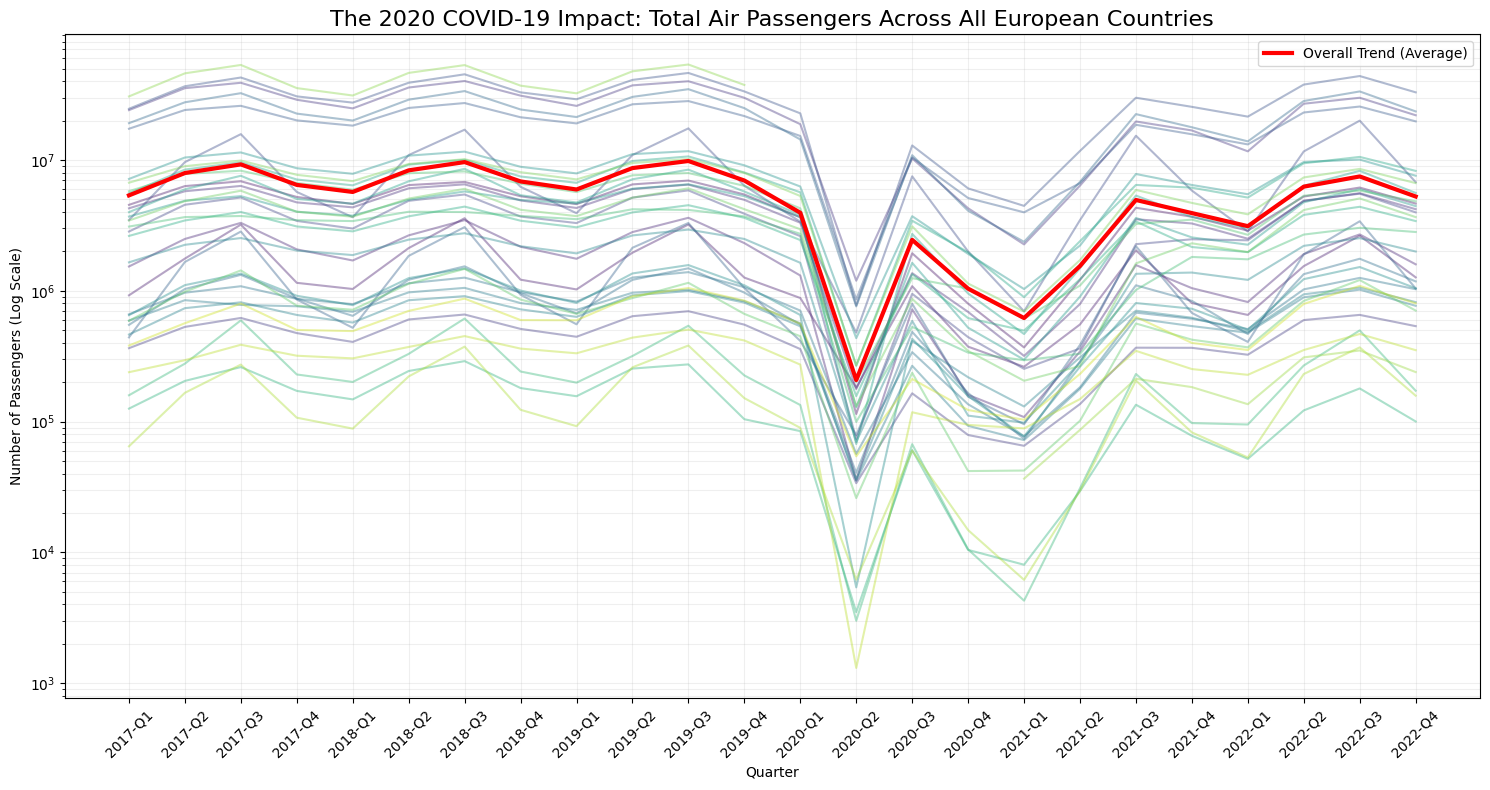

In [18]:
# Done with AI
# 1. Filter out the Aggregate totals (EU-27, etc.) so they don't squash the individual countries
# We also filter for the years around the pandemic to zoom in on the drop
df_countries = df_long[~df_long['Country'].str.contains('European Union|Total', case=False, na=False)]

# 2. Filter for a specific window (e.g., 2017 to 2023) to see the 'before and after'
# This cleans up the X-axis significantly
covid_window = [q for q in df_long['Quarter'].unique() if '2017' in str(q) or '2018' in str(q) or '2019' in str(q) or '2020' in str(q) or '2021' in str(q) or '2022' in str(q)]
df_covid = df_countries[df_countries['Quarter'].isin(covid_window)]

# 3. Create the Visualization
plt.figure(figsize=(15, 8))

# We use a semi-transparent line (alpha=0.3) for all countries 
# and a thick line for the average to show the general trend
sns.lineplot(
    data=df_covid, 
    x='Quarter', 
    y='Passengers', 
    hue='Country', 
    legend=False, 
    alpha=0.4, 
    palette='viridis'
)

# Overlay the "Mean" trend in bright red to show the collective impact
sns.lineplot(
    data=df_covid, 
    x='Quarter', 
    y='Passengers', 
    color='red', 
    linewidth=3, 
    label='Overall Trend (Average)',
    estimator='mean',
    errorbar=None
)

plt.yscale('log') # Using a Log Scale allows us to see small and large countries together
plt.title('The 2020 COVID-19 Impact: Total Air Passengers Across All European Countries', fontsize=16)
plt.ylabel('Number of Passengers (Log Scale)')
plt.xlabel('Quarter')
plt.xticks(rotation=45)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()